In [ ]:
# Importamos paqueterías
import requests
import pandas as pd
import json
from google.colab import data_table
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LassoCV, Lasso
from sklearn.linear_model import ElasticNetCV, ElasticNet
from tabulate import tabulate

# **Carga de datos**

## Series de BANXICO

In [ ]:
# Definimos el token de Banxico
token_banxico = "a9525e75ebc63fe5d45c1c164f8d2d35ae6c9e9b58c4bfa6d4827fe4d3998f35"
id_series = ["SF282", "SF18561", "SL11298", "SL138", "SR17693"]
fecha_inicio = "2015-01-01"
fecha_fin = "2024-12-01"

# Obtenemos datos de Banxico
def get_banxico_data(series, token, fecha_inicio, fecha_fin):
    url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{','.join(series)}/datos/{fecha_inicio}/{fecha_fin}?token={token}"
    response = requests.get(url)
    data = response.json()
    series_data = {s["idSerie"]: pd.DataFrame(s["datos"]) for s in data["bmx"]["series"]}
    for key in series_data:
        series_data[key]['fecha'] = pd.to_datetime(series_data[key]['fecha'])
        series_data[key]['dato'] = pd.to_numeric(series_data[key]['dato'], errors='coerce')

    return series_data

banxico_series = get_banxico_data(id_series, token_banxico, fecha_inicio, fecha_fin)

# Renombrar las series obtenidas
tasa_cetes = banxico_series["SF282"]
tipo_cambio = banxico_series["SF18561"]
salario_minimo = banxico_series["SL11298"]
salario_contractual = banxico_series["SL138"]
igae = banxico_series["SR17693"]


In [ ]:
# Creamos un DataFrame combinando todas las series
df = tasa_cetes.rename(columns={'dato': 'Tasa Cetes'}).merge(
    tipo_cambio.rename(columns={'dato': 'Tipo de Cambio'}), on='fecha', how='outer'
).merge(
    salario_minimo.rename(columns={'dato': 'Salario Mínimo'}), on='fecha', how='outer'
).merge(
    salario_contractual.rename(columns={'dato': 'Salario Contractual'}), on='fecha', how='outer'
).merge(
    igae.rename(columns={'dato': 'IGAE'}), on='fecha', how='outer'
)

df = df.drop(columns=["fecha"])

# Para mostrar una tabla interactiva
data_table.DataTable(df)



,Tasa Cetes,Tipo de Cambio,Salario Mínimo,Salario Contractual,IGAE
0,2.67,14.6808,68.33,4.33890,93.1955
1,2.81,14.9231,68.33,4.37545,93.4590
2,3.04,15.2136,68.33,4.29876,93.6275
3,2.97,15.2208,69.26,4.08846,94.5241
4,2.98,15.2640,69.26,4.40610,93.8419
...,...,...,...,...,...
115,10.76,19.1035,248.93,8.45398,105.2741
116,10.44,19.6321,248.93,8.52026,105.3753
117,10.24,19.6883,248.93,7.25162,104.5557
118,10.05,20.3313,248.93,3.60779,104.8730


## Series de INEGI

In [ ]:
# Indicadores con el primer token
indicadores1 = {
    "444666": "TD",
    "444665": "TPL",
    "702135": "IGREMSE",
    "741103": "FBKF",
    "454186": "ICC",
    "740988": "IMCPMI",
    "454549": "IMMEX",
    "673095": "INPP",
    "910413": "INPC",
    "214300": "IISBSM",
    "214310": "TEM",
    "214312": "ICE",
    "214314": "IPCBMV",
    "214318": "TIIE",
    "214320": "SP500",
    "214298": "IAI",
    "208434": "IMCPMI-Exp",
    "208441": "IMCPMI-Imp",
    "208451": "IMCPMI-Saldos",
    "436140": "SICC"
}

# Token de acceso de INEGI (Primer conjunto)
token_inegi1 = "d26ee819-4458-aa7c-7dda-899d255804dd"

# Indicadores con el segundo token
indicadores2 = {
    "436142": "SICA",
    "737301": "IGAESFYG",
    "214313": "IPCBMVCC"
}

# Token de acceso de INEGI (Segundo conjunto)
token_inegi2 = "34c2397f-93c7-cfd5-be72-16b6200b0429"

# URL base
url_base = "https://www.inegi.org.mx/app/api/indicadores/desarrolladores/jsonxml/INDICATOR/{}/es/0700/false/BIE/2.0/{}?type=json"

# Función para obtener datos del indicador
def get_inegi_data(indicador, nombre, token):
    url = url_base.format(indicador, token)
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        df = pd.DataFrame(data["Series"][0]["OBSERVATIONS"])
        df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
        df["TIME_PERIOD"] = pd.to_datetime(df["TIME_PERIOD"] + "-01")  # Convertir fecha
        df["INDICADOR"] = nombre  # Agregar nombre del indicador
        return df
    else:
        print(f"Error con indicador {indicador}: {response.status_code}")
        return None

# Procesamos los datos del primer conjunto de indicadores
data_frames1 = [get_inegi_data(ind, name, token_inegi1) for ind, name in indicadores1.items()]
data_frames1 = [df for df in data_frames1 if df is not None and not df.empty]
inegi_data1 = pd.concat(data_frames1, ignore_index=True)

# Procesamos los datos del segundo conjunto de indicadores
data_frames2 = [get_inegi_data(ind, name, token_inegi2) for ind, name in indicadores2.items()]
data_frames2 = [df for df in data_frames2 if df is not None and not df.empty]
inegi_data2 = pd.concat(data_frames2, ignore_index=True)

# Unimos ambos conjuntos de datos
inegi_data = pd.concat([inegi_data1, inegi_data2], ignore_index=True)

# Filtramos datos entre 2015 y 2024
inegi_data = inegi_data[
    (inegi_data["TIME_PERIOD"] >= "2015-01-01") & (inegi_data["TIME_PERIOD"] <= "2024-12-01")
]

# Ajustamos la fecha al primer día del trimestre si el dato es trimestral
inegi_data["TIME_PERIOD"] = inegi_data["TIME_PERIOD"].dt.to_period("M")  # Convertir a formato mensual

# Expandimos los datos trimestrales a frecuencia mensual
inegi_data = inegi_data.pivot(index="TIME_PERIOD", columns="INDICADOR", values="OBS_VALUE").ffill().reset_index()

inegi_data = inegi_data.bfill().ffill()
inegi_data = inegi_data.rename(columns={"TIME_PERIOD": "fecha"})

# Convertimos a formato fecha
inegi_data["fecha"] = inegi_data["fecha"].dt.to_timestamp()

# Reducimos decimales
inegi_data = inegi_data.round(6)

inegi_data = inegi_data.drop(columns=["fecha"])

# Tabla interactiva
data_table.DataTable(inegi_data)


INDICADOR,FBKF,IAI,ICC,ICE,IGAESFYG,IGREMSE,IISBSM,IMCPMI,IMCPMI-Exp,IMCPMI-Imp,...,INPP,IPCBMV,IPCBMVCC,SICA,SICC,SP500,TD,TEM,TIIE,TPL
0,1.011823,-0.019958,37.951288,-0.199415,65.442000,0.239259,0.080187,0.292770,24495.511925,26790.410555,...,79.777648,-0.035798,99.897734,-1.557632,0.000000,-0.011958,4.512434,0.131618,-0.022481,58.932875
1,-2.788550,-0.000234,38.396962,-0.193222,64.644000,0.193075,0.074353,0.140550,27864.650804,26874.844482,...,79.842851,0.004114,99.901847,0.843882,-0.108578,-0.024286,4.331263,0.161504,-0.023063,59.450003
2,1.288748,0.021623,38.853135,-0.166836,68.931426,-0.447756,0.066084,0.138732,32216.839117,30943.068264,...,80.461061,0.026165,99.928013,-0.104603,0.652174,-0.049531,3.862166,0.117883,-0.026580,59.300970
3,3.550122,0.057095,37.926856,-0.137207,70.096283,0.078859,0.061765,0.317536,30456.182155,30199.895065,...,80.596537,0.035169,99.963182,1.675393,0.755940,-0.082356,4.310670,0.115488,-0.031145,59.255965
4,-2.153503,0.088446,37.765951,-0.104798,65.149000,0.552905,0.061236,0.327188,30094.246761,31171.354739,...,80.486211,0.026751,99.989933,-1.029866,-0.857449,-0.123583,4.445834,0.125243,-0.035085,59.833548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,-2.216854,-0.152318,47.619891,-0.168490,120.692000,1.371419,-0.056776,-0.012555,49691.689547,53258.817050,...,127.244098,-0.121323,99.870702,-1.569714,-0.395648,0.103055,3.037372,-0.085562,-0.121182,60.192452
116,-0.761492,-0.217278,47.162349,-0.181183,115.722000,-0.205686,-0.056617,-0.449051,48836.810500,48132.964376,...,128.019818,-0.108754,99.761948,-0.656660,0.297915,0.101720,2.922514,-0.120189,-0.135498,59.974784
117,-0.020663,-0.290222,49.234818,-0.183600,104.653000,0.830632,-0.057962,-0.945991,53327.388279,52402.446838,...,128.506452,-0.094507,99.667441,-0.188857,-0.891089,0.097272,2.500182,-0.154209,-0.150116,60.230403
118,-0.152627,-0.342755,47.542664,-0.188200,108.161000,0.376068,-0.057237,0.502336,50330.308381,49746.721680,...,129.709302,-0.069570,99.597871,-0.283822,0.000000,0.080945,2.638833,-0.176325,-0.164008,60.045171


## Datos de excel

In [ ]:
# Cargar datos de Excel
precio_petroleo = pd.read_excel("/content/PrecioPetroleo.xlsx", sheet_name="Petroleo")
pib_men = pd.read_excel("/content/PrecioPetroleo.xlsx", sheet_name="PIB")

precio_petroleo = precio_petroleo.dropna(axis=1, how='all')
precio_petroleo = precio_petroleo.round(6)

pib_men = pib_men.dropna(axis=1, how='all')
pib_men = pib_men.round(6)

datosexcel = pd.merge(precio_petroleo, pib_men, on="Fecha", how="outer")  # Usa "outer" si quieres conservar todos los datos
datosexcel = datosexcel.drop(columns=["Fecha"])

data_table.DataTable(datosexcel)

,Precio,PIB
0,35.656364,2.972274
1,40.328500,2.928912
2,46.290909,2.885550
3,47.559091,2.704552
4,49.002857,2.523553
...,...,...
115,67.282273,1.847361
116,58.515714,1.647180
117,60.931739,1.287323
118,55.280952,0.927466


## Base de datos completa

In [ ]:
# Unimos los datos de Banxico, INEGI y Excel en un solo DataFrame
VariablesMacroeconomicas = pd.concat([df, inegi_data, datosexcel], axis=1)
data_table.DataTable(VariablesMacroeconomicas)


,Tasa Cetes,Tipo de Cambio,Salario Mínimo,Salario Contractual,IGAE,FBKF,IAI,ICC,ICE,IGAESFYG,...,IPCBMVCC,SICA,SICC,SP500,TD,TEM,TIIE,TPL,Precio,PIB
0,2.67,14.6808,68.33,4.33890,93.1955,1.011823,-0.019958,37.951288,-0.199415,65.442000,...,99.897734,-1.557632,0.000000,-0.011958,4.512434,0.131618,-0.022481,58.932875,35.656364,2.972274
1,2.81,14.9231,68.33,4.37545,93.4590,-2.788550,-0.000234,38.396962,-0.193222,64.644000,...,99.901847,0.843882,-0.108578,-0.024286,4.331263,0.161504,-0.023063,59.450003,40.328500,2.928912
2,3.04,15.2136,68.33,4.29876,93.6275,1.288748,0.021623,38.853135,-0.166836,68.931426,...,99.928013,-0.104603,0.652174,-0.049531,3.862166,0.117883,-0.026580,59.300970,46.290909,2.885550
3,2.97,15.2208,69.26,4.08846,94.5241,3.550122,0.057095,37.926856,-0.137207,70.096283,...,99.963182,1.675393,0.755940,-0.082356,4.310670,0.115488,-0.031145,59.255965,47.559091,2.704552
4,2.98,15.2640,69.26,4.40610,93.8419,-2.153503,0.088446,37.765951,-0.104798,65.149000,...,99.989933,-1.029866,-0.857449,-0.123583,4.445834,0.125243,-0.035085,59.833548,49.002857,2.523553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,10.76,19.1035,248.93,8.45398,105.2741,-2.216854,-0.152318,47.619891,-0.168490,120.692000,...,99.870702,-1.569714,-0.395648,0.103055,3.037372,-0.085562,-0.121182,60.192452,67.282273,1.847361
116,10.44,19.6321,248.93,8.52026,105.3753,-0.761492,-0.217278,47.162349,-0.181183,115.722000,...,99.761948,-0.656660,0.297915,0.101720,2.922514,-0.120189,-0.135498,59.974784,58.515714,1.647180
117,10.24,19.6883,248.93,7.25162,104.5557,-0.020663,-0.290222,49.234818,-0.183600,104.653000,...,99.667441,-0.188857,-0.891089,0.097272,2.500182,-0.154209,-0.150116,60.230403,60.931739,1.287323
118,10.05,20.3313,248.93,3.60779,104.8730,-0.152627,-0.342755,47.542664,-0.188200,108.161000,...,99.597871,-0.283822,0.000000,0.080945,2.638833,-0.176325,-0.164008,60.045171,55.280952,0.927466


# **IMORA-PD Proxy**

In [ ]:
datos = pd.read_excel("/content/Proyecto 2.xlsx", sheet_name="Datos")

# Convertir la columna 'Fecha' al formato de fecha en pandas
datos["Fecha"] = pd.to_datetime(datos["Fecha"].astype(str) + "-01", format="%Y%m-%d")

# Filtrar los datos para mantener solo las fechas desde 2015-01-01 en adelante
datos = datos[datos["Fecha"] >= pd.to_datetime("2015-01-01")]

Con los datos macroeconómicos obtenidos se va a realizar el modelo macroeconómico y así explicar la relación entre la Probabilidad de incumplimiento del portafolio de tarjetas de crédito (IMORA – PD Proxy) para cada uno de los bancos.

In [ ]:
Datos = pd.concat([datos, VariablesMacroeconomicas], axis=1)

In [ ]:

# Creación del DataFrame d1
d1 = pd.DataFrame({
    "PD_TBM": Datos["TBM"], "PD_BBVA": Datos["BBVA"], "PD_Banorte": Datos["Banorte"],
    "PD_Santander": Datos["Santander"], "PD_Banamex": Datos["Banamex"],
    "Cete": Datos["Tasa Cetes"], "TC": Datos["Tipo de Cambio"], "SMG": Datos["Salario Mínimo"],
    "SC": Datos["Salario Contractual"], "IGAE": Datos["IGAE"], "INPC": Datos["INPC"],
    "INPP": Datos["INPP"], "TD": Datos["TD"], "TP": Datos["TPL"],
    "IGREMSE": Datos["IGREMSE"], "FBFK": Datos["FBKF"], "ICC": Datos["ICC"],
    "IMCPMI": Datos["IMCPMI"], "IMMEX": Datos["IMMEX"], "PP": Datos["Precio"],
    "PIB": Datos["PIB"], "IISBM": Datos["IISBSM"], "TEM": Datos["TEM"], "ICE": Datos["ICE"],
    "IPCBMV": Datos["IPCBMV"], "TIIE": Datos["TIIE"], "SP500": Datos["SP500"], "IAI": Datos["IAI"],
    "Expo": Datos["IMCPMI-Exp"], "Impo": Datos["IMCPMI-Imp"],
    "Saldos": Datos["IMCPMI-Saldos"], "SICC": Datos["SICC"], "SICA": Datos["SICA"],
    "IGAESFYG": Datos["IGAESFYG"], "IPCBMVCC": Datos["IPCBMVCC"]
})

# Convertir los valores a numéricos, eliminando comas en caso de que existan
d1 = d1.applymap(lambda x: pd.to_numeric(str(x).replace(",", ""), errors='coerce'))

# Copiar d1 a d2
d2 = d1.copy()

# Lista de bancos
bancos = ["PD_TBM", "PD_BBVA", "PD_Banorte", "PD_Santander", "PD_Banamex"]

# Transformación de los datos
scaler = StandardScaler()
for banco in d1.columns:
    if banco in bancos:
        d2[banco] = np.log((d1[banco] / 100) / (1 - (d1[banco] / 100)))
    else:
        d2[banco] = scaler.fit_transform(d1[[banco]])


<ipython-input-14-5a665043f89b>:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  d1 = d1.applymap(lambda x: pd.to_numeric(str(x).replace(",", ""), errors='coerce'))


# **Modelo de Regresión Múltiple**

**Para TBM**

                            OLS Regression Results                            
Dep. Variable:                 PD_TBM   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     34.80
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           1.81e-31
Time:                        20:35:03   Log-Likelihood:                 104.68
No. Observations:                 120   AIC:                            -183.4
Df Residuals:                     107   BIC:                            -147.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7975      0.010   -183.854      0.0

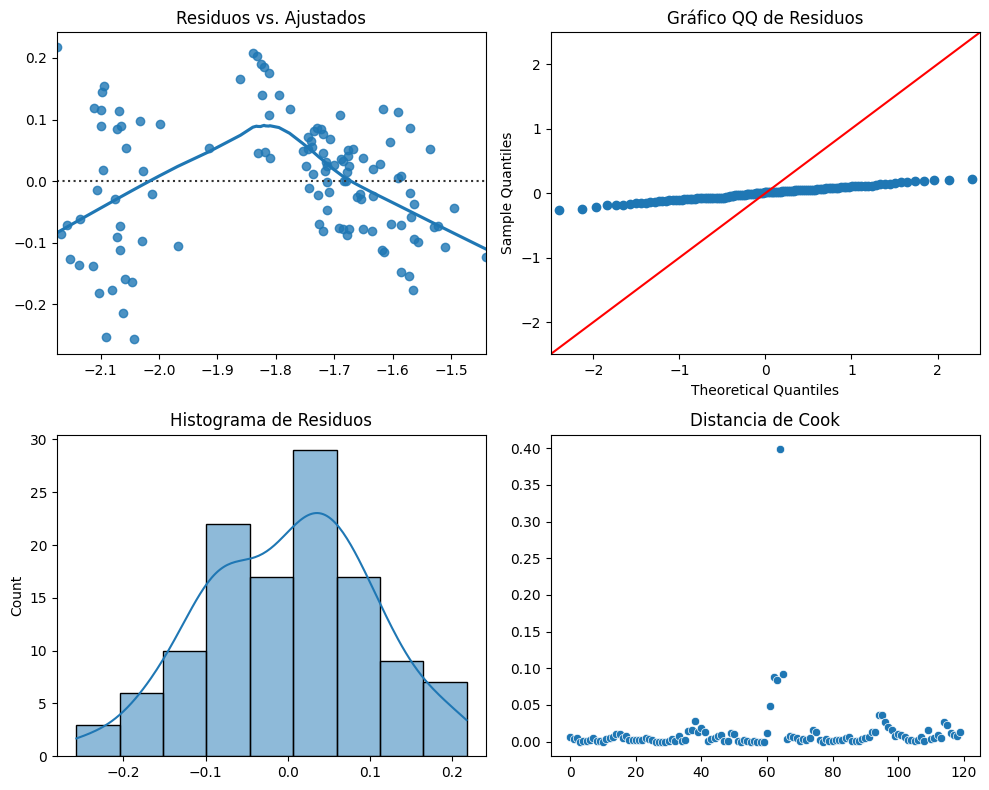

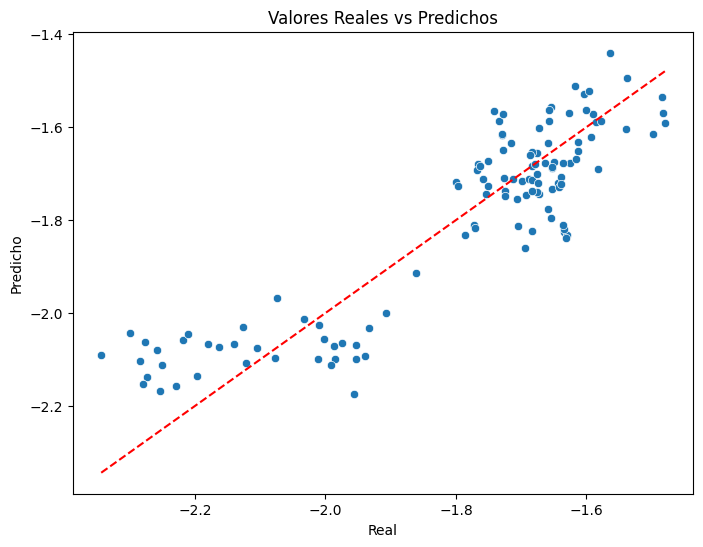

RMSE: 0.1011
MAE: 0.0830
MPE: -0.2744%
MAPE: 4.5599%
R²: 0.7960


In [ ]:

variables = ['Cete', 'SMG', 'TD', 'ICC', 'IISBM', 'TEM', 'INPP', 'TP', 'IMCPMI',
             'SP500', 'Expo', 'Impo']
X = d2[variables]
y = d2['PD_TBM']

# Agregar constante para la regresión
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
mod_TBM3 = sm.OLS(y, X).fit()

# Resumen del modelo
print(mod_TBM3.summary())

# Diagnóstico del modelo: gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residual Plot
sns.residplot(x=mod_TBM3.fittedvalues, y=mod_TBM3.resid, lowess=True, ax=axes[0, 0])
axes[0, 0].set_title('Residuos vs. Ajustados')

# QQ Plot
sm.qqplot(mod_TBM3.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico QQ de Residuos')

# Histogram of residuals
sns.histplot(mod_TBM3.resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Residuos')

# Influential points (Cook’s distance)
influence = mod_TBM3.get_influence()
(c, p) = influence.cooks_distance
sns.scatterplot(x=np.arange(len(c)), y=c, ax=axes[1, 1])
axes[1, 1].set_title("Distancia de Cook")

plt.tight_layout()
plt.show()

# Predicciones del modelo
d2['Predicción_TBM'] = mod_TBM3.predict(X)

# Gráfico de valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=d2['PD_TBM'], y=d2['Predicción_TBM'])
plt.plot([d2['PD_TBM'].min(), d2['PD_TBM'].max()],
         [d2['PD_TBM'].min(), d2['PD_TBM'].max()], color='red', linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores Reales vs Predichos")
plt.show()

# Cálculo de métricas de desempeño
rmse = np.sqrt(mean_squared_error(y, d2['Predicción_TBM']))
mae = mean_absolute_error(y, d2['Predicción_TBM'])
mpe = np.mean((y - d2['Predicción_TBM']) / y) * 100
mape = np.mean(np.abs((y - d2['Predicción_TBM']) / y)) * 100
r_squared = r2_score(y, d2['Predicción_TBM'])

metricasRM1_TBM = [rmse, mae, mpe, mape, r_squared]

# Imprimir métricas
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MPE: {mpe:.4f}%")
print(f"MAPE: {mape:.4f}%")
print(f"R²: {r_squared:.4f}")


**Para BBVA**

                            OLS Regression Results                            
Dep. Variable:                PD_BBVA   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     27.34
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           5.44e-23
Time:                        20:35:04   Log-Likelihood:                 97.741
No. Observations:                 120   AIC:                            -177.5
Df Residuals:                     111   BIC:                            -152.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8891      0.010   -185.737      0.0

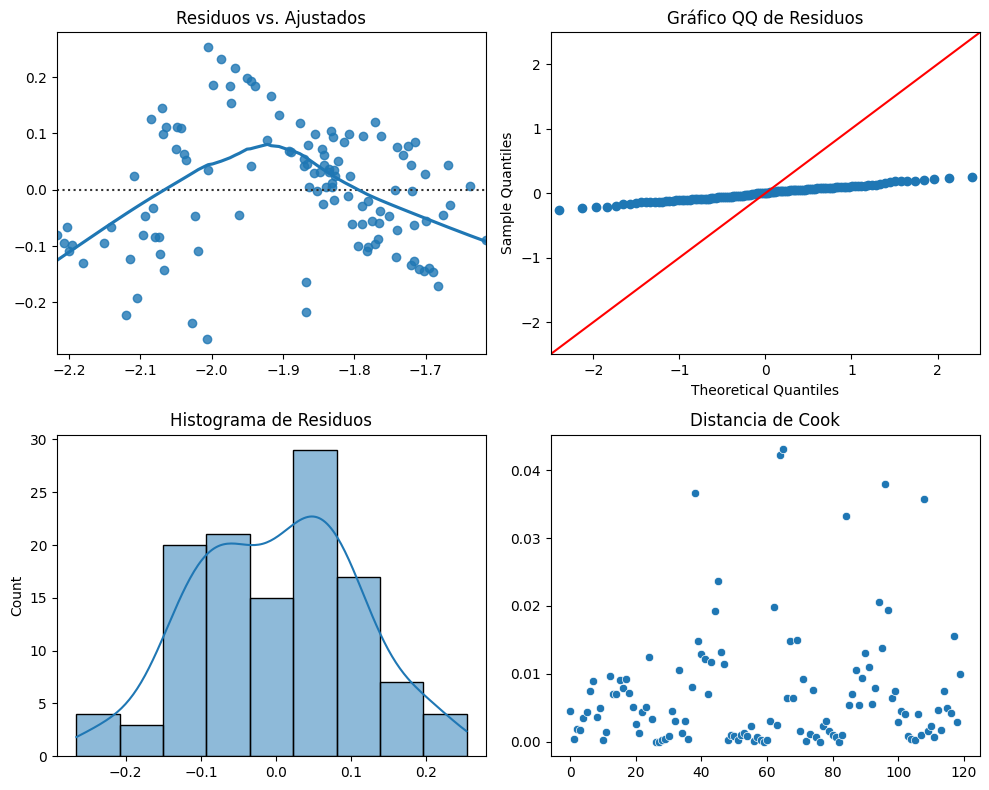

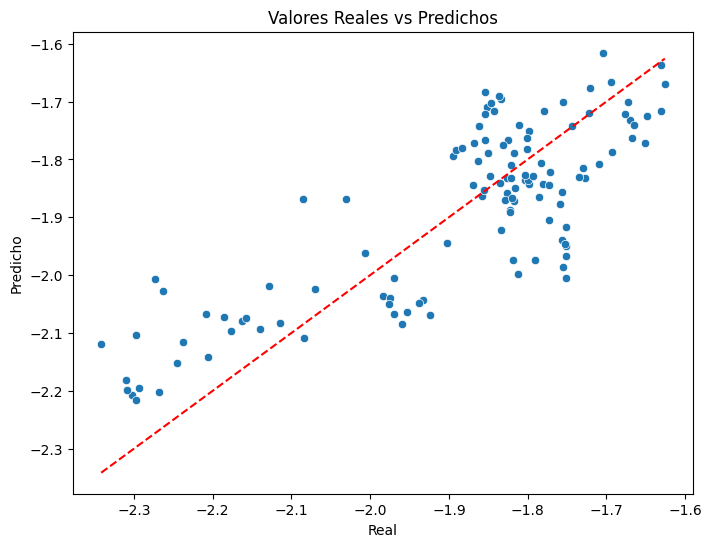

RMSE: 0.1072
MAE: 0.0889
MPE: -0.2973%
MAPE: 4.6833%
R²: 0.6634


In [ ]:
# Variables independientes y dependiente para el modelo final
variables_BBVA = ['Cete', 'TD', 'TP', 'ICC', 'IISBM', 'TEM', 'SP500', 'Expo']
X_BBVA = d2[variables_BBVA]
y_BBVA = d2['PD_BBVA']

# Agregar constante para la regresión
X_BBVA = sm.add_constant(X_BBVA)

# Ajustar el modelo de regresión lineal
mod_BBVA3 = sm.OLS(y_BBVA, X_BBVA).fit()

# Resumen del modelo
print(mod_BBVA3.summary())

# Diagnóstico del modelo: gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residual Plot
sns.residplot(x=mod_BBVA3.fittedvalues, y=mod_BBVA3.resid, lowess=True, ax=axes[0, 0])
axes[0, 0].set_title('Residuos vs. Ajustados')

# QQ Plot
sm.qqplot(mod_BBVA3.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico QQ de Residuos')

# Histograma de residuos
sns.histplot(mod_BBVA3.resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Residuos')

# Influential points (Cook’s distance)
influence_BBVA = mod_BBVA3.get_influence()
(c_BBVA, p_BBVA) = influence_BBVA.cooks_distance
sns.scatterplot(x=np.arange(len(c_BBVA)), y=c_BBVA, ax=axes[1, 1])
axes[1, 1].set_title("Distancia de Cook")

plt.tight_layout()
plt.show()

# Predicciones del modelo
d2['Predicción_BBVA'] = mod_BBVA3.predict(X_BBVA)

# Gráfico de valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=d2['PD_BBVA'], y=d2['Predicción_BBVA'])
plt.plot([d2['PD_BBVA'].min(), d2['PD_BBVA'].max()],
         [d2['PD_BBVA'].min(), d2['PD_BBVA'].max()], color='red', linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores Reales vs Predichos")
plt.show()

# Cálculo de métricas de desempeño
rmse_BBVA = np.sqrt(mean_squared_error(y_BBVA, d2['Predicción_BBVA']))
mae_BBVA = mean_absolute_error(y_BBVA, d2['Predicción_BBVA'])
mpe_BBVA = np.mean((y_BBVA - d2['Predicción_BBVA']) / y_BBVA) * 100
mape_BBVA = np.mean(np.abs((y_BBVA - d2['Predicción_BBVA']) / y_BBVA)) * 100
r_squared_BBVA = r2_score(y_BBVA, d2['Predicción_BBVA'])

metricasRM1_BBVA = [rmse_BBVA, mae_BBVA, mpe_BBVA, mape_BBVA, r_squared_BBVA]

# Imprimir métricas
print(f"RMSE: {rmse_BBVA:.4f}")
print(f"MAE: {mae_BBVA:.4f}")
print(f"MPE: {mpe_BBVA:.4f}%")
print(f"MAPE: {mape_BBVA:.4f}%")
print(f"R²: {r_squared_BBVA:.4f}")

**Para Banorte**

                            OLS Regression Results                            
Dep. Variable:             PD_Banorte   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     40.71
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           2.19e-33
Time:                        20:35:05   Log-Likelihood:                 93.942
No. Observations:                 120   AIC:                            -163.9
Df Residuals:                     108   BIC:                            -130.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7600      0.011   -165.370      0.0

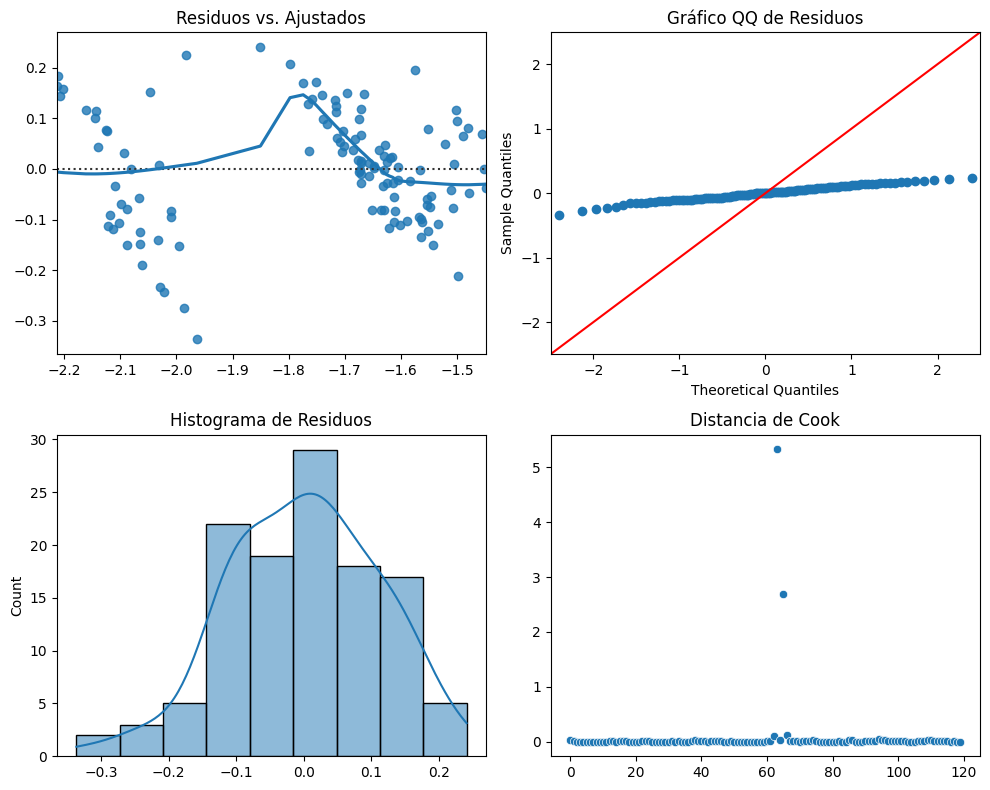

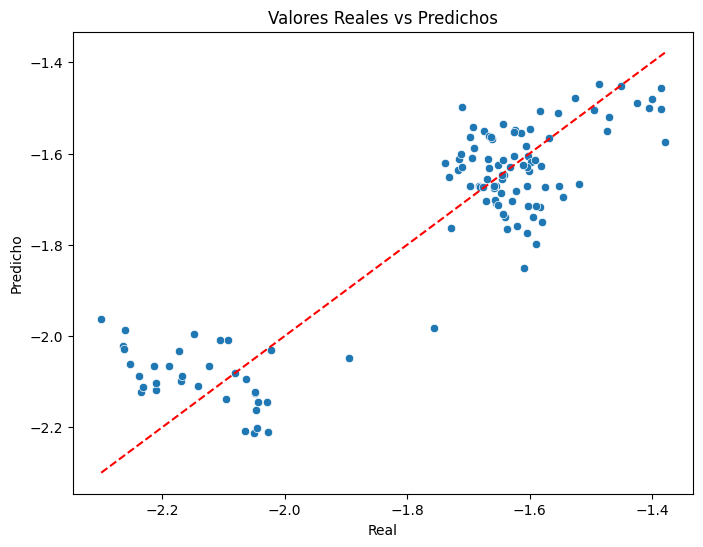

RMSE: 0.1106
MAE: 0.0890
MPE: -0.3615%
MAPE: 4.9899%
R²: 0.8057


In [ ]:
# Variables independientes y dependiente para el modelo final
variables_Banorte = ['Cete', 'SMG', 'INPP', 'TD', 'ICC', 'IMCPMI', 'IISBM', 'TEM', 'SP500', 'IAI', 'Expo']
X_Banorte = d2[variables_Banorte]
y_Banorte = d2['PD_Banorte']

# Agregar constante para la regresión
X_Banorte = sm.add_constant(X_Banorte)

# Ajustar el modelo de regresión lineal
mod_Banorte2 = sm.OLS(y_Banorte, X_Banorte).fit()

# Resumen del modelo
print(mod_Banorte2.summary())

# Diagnóstico del modelo: gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residual Plot
sns.residplot(x=mod_Banorte2.fittedvalues, y=mod_Banorte2.resid, lowess=True, ax=axes[0, 0])
axes[0, 0].set_title('Residuos vs. Ajustados')

# QQ Plot
sm.qqplot(mod_Banorte2.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico QQ de Residuos')

# Histograma de residuos
sns.histplot(mod_Banorte2.resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Residuos')

# Influential points (Cook’s distance)
influence_Banorte = mod_Banorte2.get_influence()
(c_Banorte, p_Banorte) = influence_Banorte.cooks_distance
sns.scatterplot(x=np.arange(len(c_Banorte)), y=c_Banorte, ax=axes[1, 1])
axes[1, 1].set_title("Distancia de Cook")

plt.tight_layout()
plt.show()

# Predicciones del modelo
d2['Predicción_Banorte'] = mod_Banorte2.predict(X_Banorte)

# Gráfico de valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=d2['PD_Banorte'], y=d2['Predicción_Banorte'])
plt.plot([d2['PD_Banorte'].min(), d2['PD_Banorte'].max()],
         [d2['PD_Banorte'].min(), d2['PD_Banorte'].max()], color='red', linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores Reales vs Predichos")
plt.show()

# Cálculo de métricas de desempeño
rmse_Banorte = np.sqrt(mean_squared_error(y_Banorte, d2['Predicción_Banorte']))
mae_Banorte = mean_absolute_error(y_Banorte, d2['Predicción_Banorte'])
mpe_Banorte = np.mean((y_Banorte - d2['Predicción_Banorte']) / y_Banorte) * 100
mape_Banorte = np.mean(np.abs((y_Banorte - d2['Predicción_Banorte']) / y_Banorte)) * 100
r_squared_Banorte = r2_score(y_Banorte, d2['Predicción_Banorte'])

metricasRM1_Banorte = [rmse_Banorte, mae_Banorte, mpe_Banorte, mape_Banorte, r_squared_Banorte]

# Imprimir métricas
print(f"RMSE: {rmse_Banorte:.4f}")
print(f"MAE: {mae_Banorte:.4f}")
print(f"MPE: {mpe_Banorte:.4f}%")
print(f"MAPE: {mape_Banorte:.4f}%")
print(f"R²: {r_squared_Banorte:.4f}")

**Para Santander**

                            OLS Regression Results                            
Dep. Variable:           PD_Santander   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     14.22
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           4.13e-13
Time:                        20:35:06   Log-Likelihood:                 94.140
No. Observations:                 120   AIC:                            -172.3
Df Residuals:                     112   BIC:                            -150.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7531      0.010   -168.022      0.0

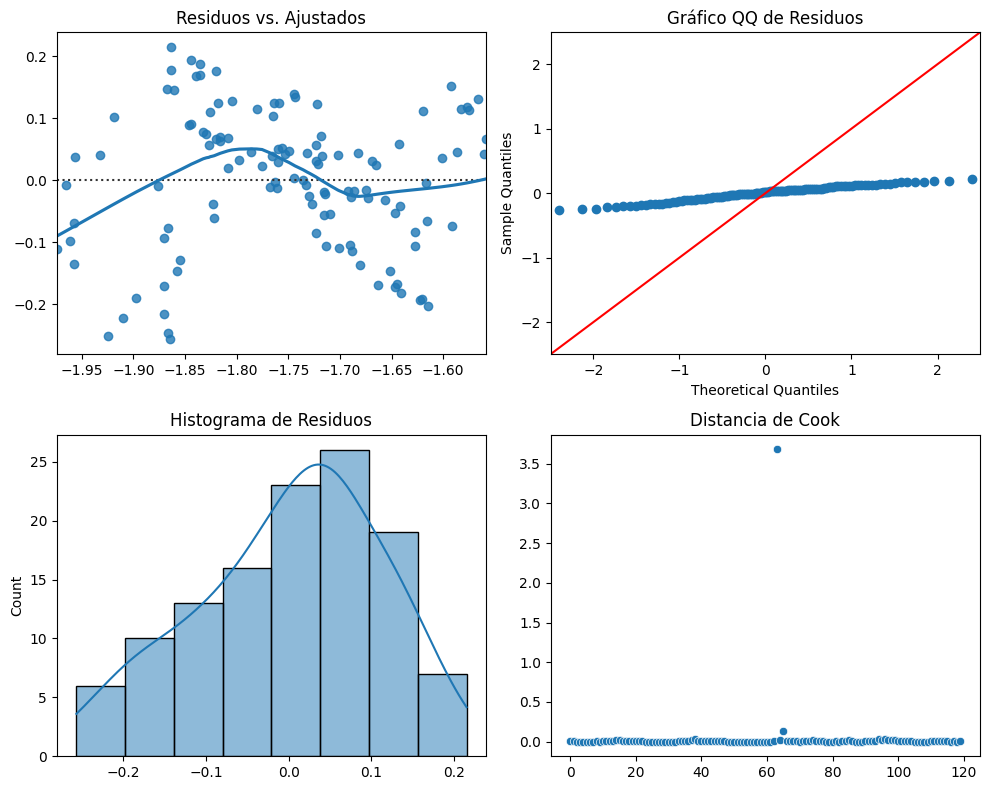

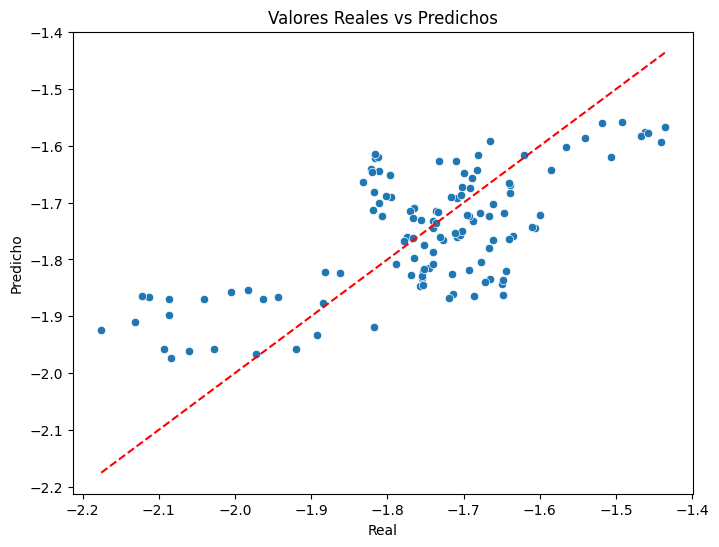

RMSE: 0.1104
MAE: 0.0904
MPE: -0.3799%
MAPE: 5.1192%
R²: 0.4706


In [ ]:
# Variables independientes y dependiente para el modelo final
variables_Santander = ['Cete', 'TD', 'ICC', 'IISBM', 'TEM', 'SP500', 'Expo']
X_Santander = d2[variables_Santander]
y_Santander = d2['PD_Santander']

# Agregar constante para la regresión
X_Santander = sm.add_constant(X_Santander)

# Ajustar el modelo de regresión lineal
mod_Santander2 = sm.OLS(y_Santander, X_Santander).fit()

# Resumen del modelo
print(mod_Santander2.summary())

# Diagnóstico del modelo: gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residual Plot
sns.residplot(x=mod_Santander2.fittedvalues, y=mod_Santander2.resid, lowess=True, ax=axes[0, 0])
axes[0, 0].set_title('Residuos vs. Ajustados')

# QQ Plot
sm.qqplot(mod_Santander2.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico QQ de Residuos')

# Histograma de residuos
sns.histplot(mod_Santander2.resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Residuos')

# Influential points (Cook’s distance)
influence_Santander = mod_Santander2.get_influence()
(c_Santander, p_Santander) = influence_Santander.cooks_distance
sns.scatterplot(x=np.arange(len(c_Santander)), y=c_Santander, ax=axes[1, 1])
axes[1, 1].set_title("Distancia de Cook")

plt.tight_layout()
plt.show()

# Predicciones del modelo
d2['Predicción_Santander'] = mod_Santander2.predict(X_Santander)

# Gráfico de valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=d2['PD_Santander'], y=d2['Predicción_Santander'])
plt.plot([d2['PD_Santander'].min(), d2['PD_Santander'].max()],
         [d2['PD_Santander'].min(), d2['PD_Santander'].max()], color='red', linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores Reales vs Predichos")
plt.show()

# Cálculo de métricas de desempeño
rmse_Santander = np.sqrt(mean_squared_error(y_Santander, d2['Predicción_Santander']))
mae_Santander = mean_absolute_error(y_Santander, d2['Predicción_Santander'])
mpe_Santander = np.mean((y_Santander - d2['Predicción_Santander']) / y_Santander) * 100
mape_Santander = np.mean(np.abs((y_Santander - d2['Predicción_Santander']) / y_Santander)) * 100
r_squared_Santander = r2_score(y_Santander, d2['Predicción_Santander'])

metricasRM1_Santander = [rmse_Santander, mae_Santander, mpe_Santander, mape_Santander, r_squared_Santander]

# Imprimir métricas
print(f"RMSE: {rmse_Santander:.4f}")
print(f"MAE: {mae_Santander:.4f}")
print(f"MPE: {mpe_Santander:.4f}%")
print(f"MAPE: {mape_Santander:.4f}%")
print(f"R²: {r_squared_Santander:.4f}")

**Para Banamex**

                            OLS Regression Results                            
Dep. Variable:             PD_Banamex   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     85.31
Date:                Wed, 19 Mar 2025   Prob (F-statistic):           5.08e-48
Time:                        20:35:07   Log-Likelihood:                 101.99
No. Observations:                 120   AIC:                            -180.0
Df Residuals:                     108   BIC:                            -146.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8266      0.010   -183.527      0.0

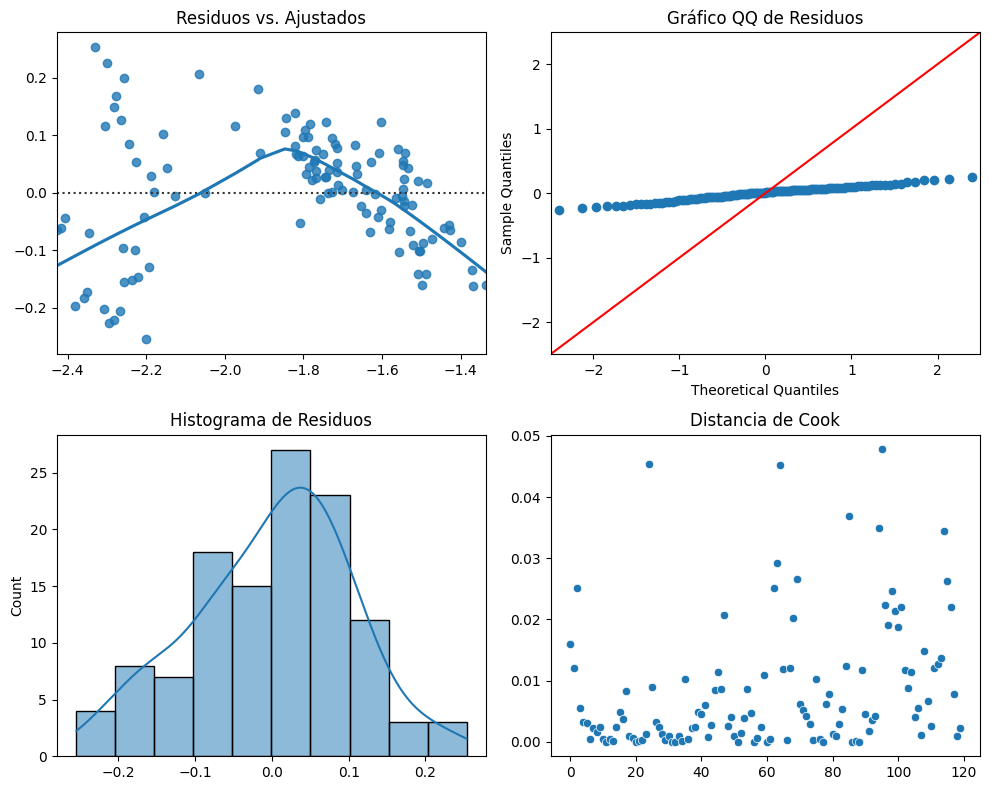

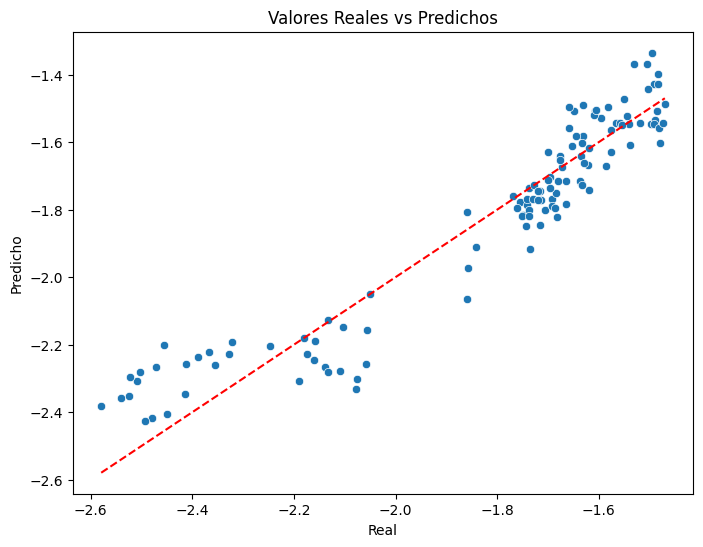

RMSE: 0.1034
MAE: 0.0828
MPE: -0.2195%
MAPE: 4.4216%
R²: 0.8968


In [ ]:
# Variables independientes y dependiente para el modelo final
variables_Banamex = ['Cete', 'SMG', 'INPC', 'INPP', 'TD', 'TP', 'ICC', 'PP', 'TEM', 'TIIE', 'SP500']
X_Banamex = d2[variables_Banamex]
y_Banamex = d2['PD_Banamex']

# Agregar constante para la regresión
X_Banamex = sm.add_constant(X_Banamex)

# Ajustar el modelo de regresión lineal
mod_Banamex2 = sm.OLS(y_Banamex, X_Banamex).fit()

# Resumen del modelo
print(mod_Banamex2.summary())

# Diagnóstico del modelo: gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residual Plot
sns.residplot(x=mod_Banamex2.fittedvalues, y=mod_Banamex2.resid, lowess=True, ax=axes[0, 0])
axes[0, 0].set_title('Residuos vs. Ajustados')

# QQ Plot
sm.qqplot(mod_Banamex2.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Gráfico QQ de Residuos')

# Histograma de residuos
sns.histplot(mod_Banamex2.resid, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Residuos')

# Influential points (Cook’s distance)
influence_Banamex = mod_Banamex2.get_influence()
(c_Banamex, p_Banamex) = influence_Banamex.cooks_distance
sns.scatterplot(x=np.arange(len(c_Banamex)), y=c_Banamex, ax=axes[1, 1])
axes[1, 1].set_title("Distancia de Cook")

plt.tight_layout()
plt.show()

# Predicciones del modelo
d2['Predicción_Banamex'] = mod_Banamex2.predict(X_Banamex)

# Gráfico de valores reales vs. predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=d2['PD_Banamex'], y=d2['Predicción_Banamex'])
plt.plot([d2['PD_Banamex'].min(), d2['PD_Banamex'].max()],
         [d2['PD_Banamex'].min(), d2['PD_Banamex'].max()], color='red', linestyle='--')
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Valores Reales vs Predichos")
plt.show()

# Cálculo de métricas de desempeño
rmse_Banamex = np.sqrt(mean_squared_error(y_Banamex, d2['Predicción_Banamex']))
mae_Banamex = mean_absolute_error(y_Banamex, d2['Predicción_Banamex'])
mpe_Banamex = np.mean((y_Banamex - d2['Predicción_Banamex']) / y_Banamex) * 100
mape_Banamex = np.mean(np.abs((y_Banamex - d2['Predicción_Banamex']) / y_Banamex)) * 100
r_squared_Banamex = r2_score(y_Banamex, d2['Predicción_Banamex'])

metricasRM1_Banamex = [rmse_Banamex, mae_Banamex, mpe_Banamex, mape_Banamex, r_squared_Banamex]

# Imprimir métricas
print(f"RMSE: {rmse_Banamex:.4f}")
print(f"MAE: {mae_Banamex:.4f}")
print(f"MPE: {mpe_Banamex:.4f}%")
print(f"MAPE: {mape_Banamex:.4f}%")
print(f"R²: {r_squared_Banamex:.4f}")

# **Modelo de Regresión Múltiple con penalización Ridge**

In [ ]:
# Definir la matriz de variables predictoras (X)
X = d2[["Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
        "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
        "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
        "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"]].to_numpy()

# Se define una secuencia de lambda, donde 10^3 es un valor alto con fuerte penalización y
# 10^(-2) es un valor bajo con penalización casi nula
lambda_seq = 10 ** np.arange(3, -2.1, -0.1)

**Para TBM**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


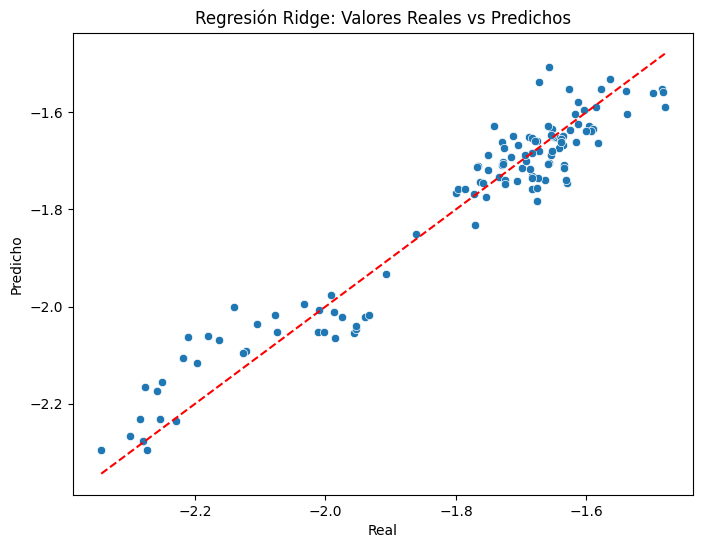

In [ ]:
# Variable respuesta (y)
y = d2["PD_TBM"].values

# Ajustar el modelo Ridge con validación cruzada
ridge_cv = RidgeCV(alphas=10 ** np.arange(3, -2.1, -0.1), store_cv_values=True)
ridge_cv.fit(X, y)

# Extraer el mejor lambda
mejor_lambda = ridge_cv.alpha_

# Ajustar modelo final con el mejor lambda
ridge_TBM = Ridge(alpha=mejor_lambda)
ridge_TBM.fit(X, y)

# Predicciones con el mejor lambda
TBM_ridge = ridge_TBM.predict(X)

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=TBM_ridge)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--")
plt.title("Regresión Ridge: Valores Reales vs Predichos")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y, TBM_ridge))  # RMSE
mae = mean_absolute_error(y, TBM_ridge)          # MAE
mpe = np.mean((y - TBM_ridge) / y) * 100         # MPE
mape = np.mean(np.abs((y - TBM_ridge) / y)) * 100  # MAPE
r_squared = r2_score(y, TBM_ridge)  # R-squared

metricasRidge_TBM = np.array([rmse, mae, mpe, mape, r_squared])

**Para BBVA**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


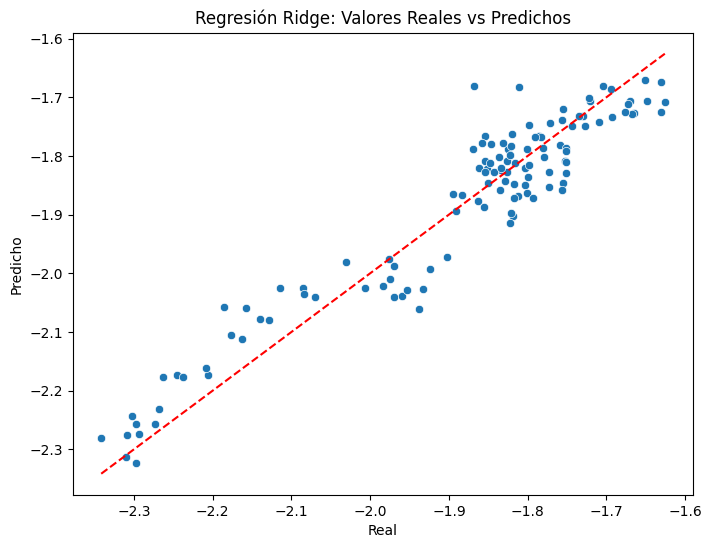

In [ ]:
# Variable respuesta (y)
y = d2["PD_BBVA"].values

# Ajustar el modelo Ridge con validación cruzada
ridge_cv = RidgeCV(alphas=10 ** np.arange(3, -2.1, -0.1), store_cv_values=True)
ridge_cv.fit(X, y)

# Extraer el mejor lambda
mejor_lambda2 = ridge_cv.alpha_

# Ajustar modelo final con el mejor lambda
ridge_BBVA = Ridge(alpha=mejor_lambda2)
ridge_BBVA.fit(X, y)

# Predicciones con el mejor lambda
BBVA_ridge = ridge_BBVA.predict(X)

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=BBVA_ridge)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--")
plt.title("Regresión Ridge: Valores Reales vs Predichos")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y, BBVA_ridge))  # RMSE
mae = mean_absolute_error(y, BBVA_ridge)          # MAE
mpe = np.mean((y - BBVA_ridge) / y) * 100         # MPE
mape = np.mean(np.abs((y - BBVA_ridge) / y)) * 100  # MAPE
r_squared = r2_score(y, BBVA_ridge)  # R-squared

metricasRidge_BBVA = np.array([rmse, mae, mpe, mape, r_squared])

**Para Banorte**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


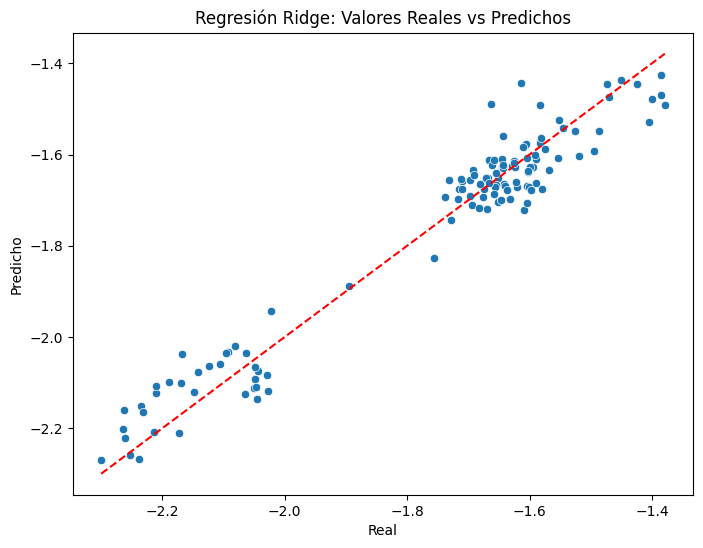

In [ ]:
# Variable respuesta (y)
y = d2["PD_Banorte"].values

# Ajustar el modelo Ridge con validación cruzada
ridge_cv = RidgeCV(alphas=10 ** np.arange(3, -2.1, -0.1), store_cv_values=True)
ridge_cv.fit(X, y)

# Extraer el mejor lambda
mejor_lambda3 = ridge_cv.alpha_

# Ajustar modelo final con el mejor lambda
ridge_Banorte = Ridge(alpha=mejor_lambda3)
ridge_Banorte.fit(X, y)

# Predicciones con el mejor lambda
Banorte_ridge = ridge_Banorte.predict(X)

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=Banorte_ridge)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--")
plt.title("Regresión Ridge: Valores Reales vs Predichos")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y, Banorte_ridge))  # RMSE
mae = mean_absolute_error(y, Banorte_ridge)          # MAE
mpe = np.mean((y - Banorte_ridge) / y) * 100         # MPE
mape = np.mean(np.abs((y - Banorte_ridge) / y)) * 100  # MAPE
r_squared = r2_score(y, Banorte_ridge)  # R-squared

metricasRidge_Banorte = np.array([rmse, mae, mpe, mape, r_squared])

**Para Santander**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


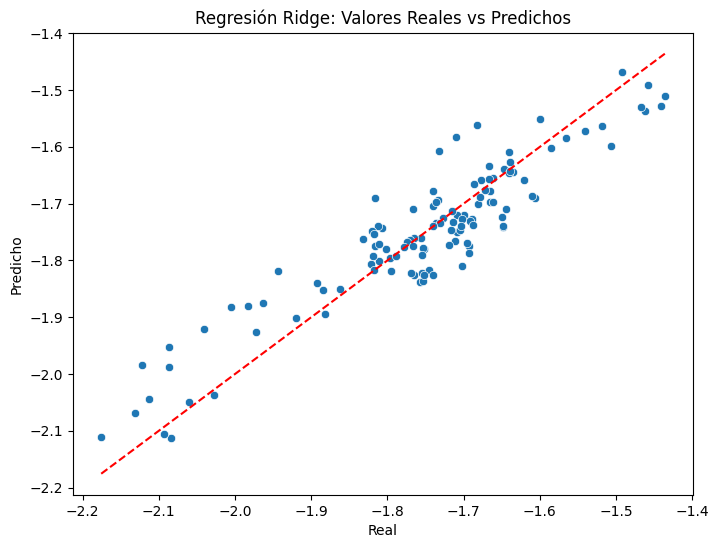

In [ ]:
# Variable respuesta (y)
y = d2["PD_Santander"].values

# Ajustar el modelo Ridge con validación cruzada
ridge_cv = RidgeCV(alphas=10 ** np.arange(3, -2.1, -0.1), store_cv_values=True)
ridge_cv.fit(X, y)

# Extraer el mejor lambda
mejor_lambda4 = ridge_cv.alpha_

# Ajustar modelo final con el mejor lambda
ridge_Santander = Ridge(alpha=mejor_lambda4)
ridge_Santander.fit(X, y)

# Predicciones con el mejor lambda
Santander_ridge = ridge_Santander.predict(X)

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=Santander_ridge)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--")
plt.title("Regresión Ridge: Valores Reales vs Predichos")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y, Santander_ridge))  # RMSE
mae = mean_absolute_error(y, Santander_ridge)          # MAE
mpe = np.mean((y - Santander_ridge) / y) * 100         # MPE
mape = np.mean(np.abs((y - Santander_ridge) / y)) * 100  # MAPE
r_squared = r2_score(y, Santander_ridge)  # R-squared

metricasRidge_San = np.array([rmse, mae, mpe, mape, r_squared])

**Para Banamex**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


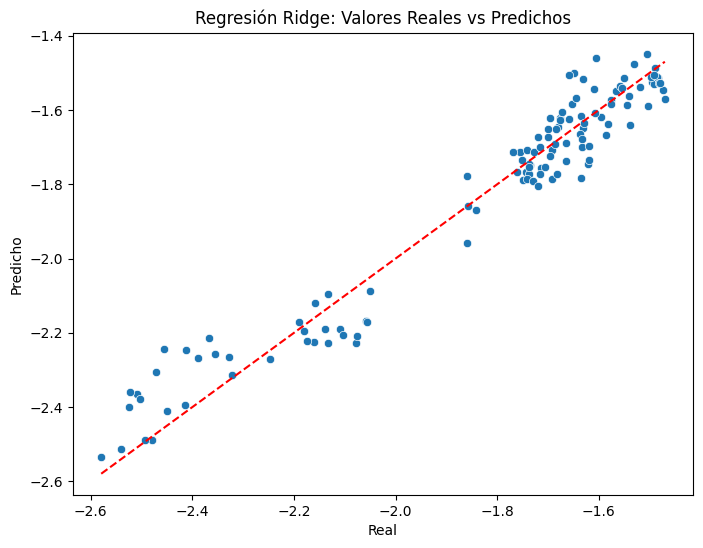

In [ ]:
# Variable respuesta (y)
y = d2["PD_Banamex"].values

# Ajustar el modelo Ridge con validación cruzada
ridge_cv = RidgeCV(alphas=10 ** np.arange(3, -2.1, -0.1), store_cv_values=True)
ridge_cv.fit(X, y)

# Extraer el mejor lambda
mejor_lambda5 = ridge_cv.alpha_

# Ajustar modelo final con el mejor lambda
ridge_Banamex = Ridge(alpha=mejor_lambda5)
ridge_Banamex.fit(X, y)

# Predicciones con el mejor lambda
Banamex_ridge = ridge_Banamex.predict(X)

# Graficar valores reales vs predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=Banamex_ridge)
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", linestyle="--")
plt.title("Regresión Ridge: Valores Reales vs Predichos")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y, Banamex_ridge))  # RMSE
mae = mean_absolute_error(y, Banamex_ridge)          # MAE
mpe = np.mean((y - Banamex_ridge) / y) * 100         # MPE
mape = np.mean(np.abs((y - Banamex_ridge) / y)) * 100  # MAPE
r_squared = r2_score(y, Banamex_ridge)  # R-squared

metricasRidge_Banamex = np.array([rmse, mae, mpe, mape, r_squared])

# **Modelo de Regresión Lasso**

**Para TBM**

In [ ]:
# Definir la matriz de variables predictoras (X) y la variable respuesta (y)
X = d2[["Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
        "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
        "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
        "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"]].values
Y = d2["PD_TBM"].values

# Ajustar modelo Lasso con validación cruzada
lasso_cv = LassoCV(alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
lasso_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_lassoTBM = lasso_cv.alpha_

# Ajustar modelo final con el mejor lambda
lasso_modelTBM = Lasso(alpha=mejor_lambda_lassoTBM)
lasso_modelTBM.fit(X, Y)

# Coeficientes del modelo
coef_lassoTBM = pd.Series(lasso_modelTBM.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_lassoTBM)

# Predicciones con el mejor lambda
Pred_lassoTBM = lasso_modelTBM.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_lassoTBM))  # RMSE
mae = mean_absolute_error(Y, Pred_lassoTBM)          # MAE
mpe = np.mean((Y - Pred_lassoTBM) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_lassoTBM) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_lassoTBM)  # R-squared

metricaslassoTBM = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.055609
TC          0.000000
SMG        -0.039112
SC         -0.027213
IGAE       -0.000000
INPC       -0.000000
INPP       -0.000000
TD          0.000000
TP         -0.000000
IGREMSE    -0.000000
FBFK       -0.000000
ICC         0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB         0.000000
IISBM      -0.000000
TEM        -0.000000
ICE         0.000000
IPCBMV      0.000000
TIIE       -0.047399
SP500       0.005994
IAI        -0.000000
Expo       -0.000000
Impo       -0.039081
Saldos      0.000000
SICC       -0.000000
SICA       -0.000000
IGAESFYG   -0.000000
IPCBMVCC    0.000000
dtype: float64


**Para BBVA**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_BBVA"].values

# Ajustar modelo Lasso con validación cruzada
lasso_cv = LassoCV(alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
lasso_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_lassoBBVA = lasso_cv.alpha_

# Ajustar modelo final con el mejor lambda
lasso_modelBBVA = Lasso(alpha=mejor_lambda_lassoBBVA)
lasso_modelBBVA.fit(X, Y)

# Coeficientes del modelo
coef_lassoBBVA = pd.Series(lasso_modelBBVA.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_lassoBBVA)

# Predicciones con el mejor lambda
Pred_lassoBBVA = lasso_modelBBVA.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_lassoBBVA))  # RMSE
mae = mean_absolute_error(Y, Pred_lassoBBVA)          # MAE
mpe = np.mean((Y - Pred_lassoBBVA) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_lassoBBVA) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_lassoBBVA)  # R-squared

metricaslassoBBVA = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.042258
TC         -0.000000
SMG        -0.030777
SC         -0.027774
IGAE       -0.000000
INPC       -0.000000
INPP       -0.037568
TD          0.000000
TP         -0.000000
IGREMSE    -0.000031
FBFK       -0.001674
ICC         0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB         0.000000
IISBM      -0.000000
TEM        -0.000000
ICE         0.000000
IPCBMV     -0.000000
TIIE       -0.060989
SP500       0.032150
IAI        -0.000000
Expo       -0.000000
Impo       -0.000000
Saldos     -0.000000
SICC       -0.000000
SICA       -0.000000
IGAESFYG   -0.000000
IPCBMVCC    0.003408
dtype: float64


**Para Banorte**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Banorte"].values

# Ajustar modelo Lasso con validación cruzada
lasso_cv = LassoCV(alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
lasso_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_lassoBae = lasso_cv.alpha_

# Ajustar modelo final con el mejor lambda
lasso_modelBae = Lasso(alpha=mejor_lambda_lassoBae)
lasso_modelBae.fit(X, Y)

# Coeficientes del modelo
coef_lassoBae = pd.Series(lasso_modelBae.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_lassoBae)

# Predicciones con el mejor lambda
Pred_lassoBae = lasso_modelBae.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_lassoBae))  # RMSE
mae = mean_absolute_error(Y, Pred_lassoBae)          # MAE
mpe = np.mean((Y - Pred_lassoBae) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_lassoBae) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_lassoBae)  # R-squared

metricaslassoBae = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.009836
TC          0.000000
SMG        -0.000000
SC         -0.000000
IGAE       -0.000000
INPC       -0.000000
INPP       -0.000000
TD          0.000000
TP         -0.000000
IGREMSE    -0.000000
FBFK       -0.000000
ICC        -0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB        -0.000000
IISBM       0.000000
TEM         0.000000
ICE         0.000000
IPCBMV      0.000000
TIIE       -0.000000
SP500       0.000000
IAI        -0.000000
Expo       -0.000000
Impo       -0.061163
Saldos      0.000000
SICC       -0.000000
SICA        0.000000
IGAESFYG   -0.000000
IPCBMVCC   -0.000000
dtype: float64


**Para Santander**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Santander"].values

# Ajustar modelo Lasso con validación cruzada
lasso_cv = LassoCV(alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
lasso_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_lassoSan = lasso_cv.alpha_

# Ajustar modelo final con el mejor lambda
lasso_modelSan = Lasso(alpha=mejor_lambda_lassoSan)
lasso_modelSan.fit(X, Y)

# Coeficientes del modelo
coef_lassoSan = pd.Series(lasso_modelSan.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_lassoSan)

# Predicciones con el mejor lambda
Pred_lassoSan = lasso_modelSan.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_lassoSan))  # RMSE
mae = mean_absolute_error(Y, Pred_lassoSan)          # MAE
mpe = np.mean((Y - Pred_lassoSan) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_lassoSan) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_lassoSan)  # R-squared

metricaslassoSan = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.0
TC          0.0
SMG        -0.0
SC         -0.0
IGAE       -0.0
INPC       -0.0
INPP       -0.0
TD          0.0
TP         -0.0
IGREMSE    -0.0
FBFK       -0.0
ICC        -0.0
IMCPMI     -0.0
IMMEX      -0.0
PP         -0.0
PIB        -0.0
IISBM       0.0
TEM         0.0
ICE         0.0
IPCBMV      0.0
TIIE       -0.0
SP500       0.0
IAI        -0.0
Expo       -0.0
Impo       -0.0
Saldos      0.0
SICC       -0.0
SICA        0.0
IGAESFYG   -0.0
IPCBMVCC   -0.0
dtype: float64


**Para Banamex**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Banamex"].values

# Ajustar modelo Lasso con validación cruzada
lasso_cv = LassoCV(alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
lasso_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_lassoBax = lasso_cv.alpha_

# Ajustar modelo final con el mejor lambda
lasso_modelBax = Lasso(alpha=mejor_lambda_lassoBax)
lasso_modelBax.fit(X, Y)

# Coeficientes del modelo
coef_lassoBax = pd.Series(lasso_modelBax.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_lassoBax)

# Predicciones con el mejor lambda
Pred_lassoBax = lasso_modelBax.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_lassoBax))  # RMSE
mae = mean_absolute_error(Y, Pred_lassoBax)          # MAE
mpe = np.mean((Y - Pred_lassoBax) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_lassoBax) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_lassoBax)  # R-squared

metricaslassoBax = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.150088
TC          0.017025
SMG        -0.126671
SC         -0.031976
IGAE        0.000000
INPC       -0.029420
INPP       -0.000000
TD          0.000000
TP         -0.000000
IGREMSE    -0.000952
FBFK       -0.005457
ICC         0.037862
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB         0.000000
IISBM      -0.000000
TEM        -0.000000
ICE         0.000000
IPCBMV     -0.004443
TIIE       -0.087901
SP500       0.026377
IAI        -0.000000
Expo       -0.000000
Impo       -0.015960
Saldos      0.000000
SICC       -0.000000
SICA       -0.000000
IGAESFYG    0.000000
IPCBMVCC    0.019054
dtype: float64


# **Modelo de Regresión Múltiple con penalización Elastic Net**

**Para TBM**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_TBM"].values

# Ajustar modelo Elastic Net con validación cruzada
elastic_cv = ElasticNetCV(l1_ratio=0.5, alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
elastic_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_ENTBM = elastic_cv.alpha_

# Ajustar modelo final con el mejor lambda
EN_modelTBM = ElasticNet(alpha=mejor_lambda_ENTBM, l1_ratio=0.5)
EN_modelTBM.fit(X, Y)

# Coeficientes del modelo
coef_ENTBM = pd.Series(EN_modelTBM.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_ENTBM)

# Predicciones con el mejor lambda
Pred_ENTBM = EN_modelTBM.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_ENTBM))  # RMSE
mae = mean_absolute_error(Y, Pred_ENTBM)          # MAE
mpe = np.mean((Y - Pred_ENTBM) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_ENTBM) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_ENTBM)  # R-squared

metricasEN_TBM = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.052829
TC          0.000000
SMG        -0.036666
SC         -0.028453
IGAE       -0.000000
INPC       -0.000000
INPP       -0.000000
TD          0.000000
TP         -0.000000
IGREMSE    -0.000000
FBFK       -0.000000
ICC        -0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB         0.000000
IISBM      -0.000000
TEM         0.000000
ICE         0.000000
IPCBMV      0.000000
TIIE       -0.045019
SP500       0.006121
IAI        -0.000000
Expo       -0.000000
Impo       -0.041504
Saldos      0.000000
SICC       -0.000000
SICA       -0.000000
IGAESFYG   -0.000000
IPCBMVCC    0.000000
dtype: float64


**Para BBVA**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_BBVA"].values

# Ajustar modelo Elastic Net con validación cruzada
elastic_cv = ElasticNetCV(l1_ratio=0.5, alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
elastic_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_ENBBVA = elastic_cv.alpha_

# Ajustar modelo final con el mejor lambda
EN_modelBBVA = ElasticNet(alpha=mejor_lambda_ENBBVA, l1_ratio=0.5)
EN_modelBBVA.fit(X, Y)

# Coeficientes del modelo
coef_ENBBVA = pd.Series(EN_modelBBVA.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_ENBBVA)

# Predicciones con el mejor lambda
Pred_ENBBVA = EN_modelBBVA.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_ENBBVA))  # RMSE
mae = mean_absolute_error(Y, Pred_ENBBVA)          # MAE
mpe = np.mean((Y - Pred_ENBBVA) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_ENBBVA) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_ENBBVA)  # R-squared

metricasEN_BBVA = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.041241
TC         -0.000000
SMG        -0.030238
SC         -0.028069
IGAE       -0.000000
INPC       -0.000000
INPP       -0.037838
TD          0.000000
TP         -0.000000
IGREMSE    -0.000219
FBFK       -0.001726
ICC         0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB         0.000000
IISBM      -0.000000
TEM        -0.000000
ICE         0.000000
IPCBMV     -0.000000
TIIE       -0.058828
SP500       0.032460
IAI        -0.000000
Expo       -0.000000
Impo       -0.000000
Saldos     -0.000000
SICC       -0.000000
SICA       -0.000000
IGAESFYG   -0.000000
IPCBMVCC    0.001939
dtype: float64


**Para Banorte**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Banorte"].values

# Ajustar modelo Elastic Net con validación cruzada
elastic_cv = ElasticNetCV(l1_ratio=0.5, alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
elastic_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_ENBae = elastic_cv.alpha_

# Ajustar modelo final con el mejor lambda
EN_modelBae = ElasticNet(alpha=mejor_lambda_ENBae, l1_ratio=0.5)
EN_modelBae.fit(X, Y)

# Coeficientes del modelo
coef_ENBae = pd.Series(EN_modelBae.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_ENBae)

# Predicciones con el mejor lambda
Pred_ENBae = EN_modelBae.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_ENBae))  # RMSE
mae = mean_absolute_error(Y, Pred_ENBae)          # MAE
mpe = np.mean((Y - Pred_ENBae) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_ENBae) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_ENBae)  # R-squared

metricasEN_Bae = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.016119
TC          0.000000
SMG        -0.000000
SC         -0.000000
IGAE       -0.000000
INPC       -0.000000
INPP       -0.000000
TD          0.000000
TP         -0.000000
IGREMSE    -0.000000
FBFK       -0.000000
ICC        -0.000000
IMCPMI     -0.000000
IMMEX      -0.000000
PP         -0.000000
PIB        -0.000000
IISBM       0.000000
TEM         0.000000
ICE         0.000000
IPCBMV      0.000000
TIIE       -0.000000
SP500       0.000000
IAI        -0.000000
Expo       -0.000000
Impo       -0.050434
Saldos      0.000000
SICC       -0.000000
SICA        0.000000
IGAESFYG   -0.000000
IPCBMVCC   -0.000000
dtype: float64


**Para Santander**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Santander"].values

# Ajustar modelo Elastic Net con validación cruzada
elastic_cv = ElasticNetCV(l1_ratio=0.5, alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
elastic_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_ENSan = elastic_cv.alpha_

# Ajustar modelo final con el mejor lambda
EN_modelSan = ElasticNet(alpha=mejor_lambda_ENSan, l1_ratio=0.5)
EN_modelSan.fit(X, Y)

# Coeficientes del modelo
coef_ENSan = pd.Series(EN_modelSan.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_ENSan)

# Predicciones con el mejor lambda
Pred_ENSan = EN_modelSan.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_ENSan))  # RMSE
mae = mean_absolute_error(Y, Pred_ENSan)          # MAE
mpe = np.mean((Y - Pred_ENSan) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_ENSan) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_ENSan)  # R-squared

metricasEN_San = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.0
TC          0.0
SMG        -0.0
SC         -0.0
IGAE       -0.0
INPC       -0.0
INPP       -0.0
TD          0.0
TP         -0.0
IGREMSE    -0.0
FBFK       -0.0
ICC        -0.0
IMCPMI     -0.0
IMMEX      -0.0
PP         -0.0
PIB        -0.0
IISBM       0.0
TEM         0.0
ICE         0.0
IPCBMV      0.0
TIIE       -0.0
SP500       0.0
IAI        -0.0
Expo       -0.0
Impo       -0.0
Saldos      0.0
SICC       -0.0
SICA        0.0
IGAESFYG   -0.0
IPCBMVCC   -0.0
dtype: float64


**Para Banamex**

In [ ]:
# Definir la variable respuesta (Y)
Y = d2["PD_Banamex"].values

# Ajustar modelo Elastic Net con validación cruzada
elastic_cv = ElasticNetCV(l1_ratio=0.5, alphas=10 ** np.arange(3, -2.1, -0.1), cv=5, random_state=123)
elastic_cv.fit(X, Y)

# Mejor valor de lambda
mejor_lambda_ENBax = elastic_cv.alpha_

# Ajustar modelo final con el mejor lambda
EN_modelBax = ElasticNet(alpha=mejor_lambda_ENBax, l1_ratio=0.5)
EN_modelBax.fit(X, Y)

# Coeficientes del modelo
coef_ENBax = pd.Series(EN_modelBax.coef_, index=[
    "Cete", "TC", "SMG", "SC", "IGAE", "INPC", "INPP", "TD", "TP",
    "IGREMSE", "FBFK", "ICC", "IMCPMI", "IMMEX", "PP", "PIB",
    "IISBM", "TEM", "ICE", "IPCBMV", "TIIE", "SP500", "IAI",
    "Expo", "Impo", "Saldos", "SICC", "SICA", "IGAESFYG", "IPCBMVCC"
])
print(coef_ENBax)

# Predicciones con el mejor lambda
Pred_ENBax = EN_modelBax.predict(X)

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(Y, Pred_ENBax))  # RMSE
mae = mean_absolute_error(Y, Pred_ENBax)          # MAE
mpe = np.mean((Y - Pred_ENBax) / Y) * 100         # MPE
mape = np.mean(np.abs((Y - Pred_ENBax) / Y)) * 100  # MAPE
r_squared = r2_score(Y, Pred_ENBax)  # R-squared

metricasEN_Bax = np.array([rmse, mae, mpe, mape, r_squared])

Cete       -0.177077
TC          0.059169
SMG        -0.094270
SC         -0.027140
IGAE        0.002111
INPC       -0.036676
INPP       -0.092958
TD         -0.000000
TP         -0.000000
IGREMSE    -0.005184
FBFK       -0.005493
ICC         0.075409
IMCPMI     -0.000000
IMMEX      -0.000000
PP          0.000000
PIB         0.000000
IISBM       0.000000
TEM         0.000000
ICE         0.000000
IPCBMV     -0.020008
TIIE       -0.106369
SP500       0.037993
IAI         0.000000
Expo       -0.000000
Impo       -0.002465
Saldos      0.000000
SICC        0.000000
SICA        0.000000
IGAESFYG    0.022646
IPCBMVCC    0.050883
dtype: float64


# **# Métricas (comparación de todos los modelos)**

**Para TBM**

In [ ]:
# Crear la tabla de métricas
tabla_metricas = pd.DataFrame({
    "Modelo": [
        "Regresión Múltiple",
        "RM con penalización Ridge",
        "RM con penalización Lasso",
        "RM con penalización Elastic Net"
    ],
    "RMSE": [metricasRM1_TBM[0], metricasRidge_TBM[0], metricaslassoTBM[0], metricasEN_TBM[0]],
    "MAE": [metricasRM1_TBM[1], metricasRidge_TBM[1], metricaslassoTBM[1], metricasEN_TBM[1]],
    "MPE": [metricasRM1_TBM[2], metricasRidge_TBM[2], metricaslassoTBM[2], metricasEN_TBM[2]],
    "MAPE": [metricasRM1_TBM[3], metricasRidge_TBM[3], metricaslassoTBM[3], metricasEN_TBM[3]],
    "R²": [metricasRM1_TBM[4], metricasRidge_TBM[4], metricaslassoTBM[4], metricasEN_TBM[4]]
})

# Mostrar la tabla con formato
print(tabulate(tabla_metricas, headers="keys", tablefmt="pretty"))


+---+---------------------------------+----------------------+---------------------+---------------------+-------------------+--------------------+
|   |             Modelo              |         RMSE         |         MAE         |         MPE         |       MAPE        |         R²         |
+---+---------------------------------+----------------------+---------------------+---------------------+-------------------+--------------------+
| 0 |       Regresión Múltiple        | 0.10113377660014966  | 0.08303861261014903 | -0.2744409589998826 | 4.559887450513629 | 0.7960183242325236 |
| 1 |    RM con penalización Ridge    | 0.059157589791030425 | 0.04709082433105056 | -0.1573154266019319 | 2.615385624778278 | 0.9302057494752195 |
| 2 |    RM con penalización Lasso    | 0.11804273524822881  | 0.0929810851024504  | -0.5800740389140363 | 5.067018887945022 | 0.7221072392084382 |
| 3 | RM con penalización Elastic Net | 0.11908688359079732  | 0.09349013417753478 | -0.5913794637134391 | 5.091

**Para BBVA**

In [ ]:
# Crear la tabla de métricas
tabla_metricas_BBVA = pd.DataFrame({
    "Modelo": [
        "Regresión Múltiple",
        "RM con penalización Ridge",
        "RM con penalización Lasso",
        "RM con penalización Elastic Net"
    ],
    "RMSE": [metricasRM1_BBVA[0], metricasRidge_BBVA[0], metricaslassoBBVA[0], metricasEN_BBVA[0]],
    "MAE": [metricasRM1_BBVA[1], metricasRidge_BBVA[1], metricaslassoBBVA[1], metricasEN_BBVA[1]],
    "MPE": [metricasRM1_BBVA[2], metricasRidge_BBVA[2], metricaslassoBBVA[2], metricasEN_BBVA[2]],
    "MAPE": [metricasRM1_BBVA[3], metricasRidge_BBVA[3], metricaslassoBBVA[3], metricasEN_BBVA[3]],
    "R²": [metricasRM1_BBVA[4], metricasRidge_BBVA[4], metricaslassoBBVA[4], metricasEN_BBVA[4]]
})

# Mostrar la tabla con formato
print(tabulate(tabla_metricas_BBVA, headers="keys", tablefmt="pretty"))

+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+--------------------+
|   |             Modelo              |        RMSE         |         MAE         |         MPE          |        MAPE        |         R²         |
+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+--------------------+
| 0 |       Regresión Múltiple        | 0.10715871387732152 | 0.08894531894990615 | -0.2973351501282323  | 4.683314794480563  | 0.6633542077684595 |
| 1 |    RM con penalización Ridge    | 0.05580610667825048 | 0.04581337857594121 | -0.12107986166564272 | 2.429425428350721  | 0.9086977131710832 |
| 2 |    RM con penalización Lasso    | 0.08764508053668521 | 0.07210341478528472 | -0.29431289120167115 | 3.753775394307193  | 0.7747974549054085 |
| 3 | RM con penalización Elastic Net | 0.08839148701318392 | 0.07279045103266357 | -0.2996565830322604  |

**Para Banorte**

In [ ]:
# Crear la tabla de métricas
tabla_metricas_Banorte = pd.DataFrame({
    "Modelo": [
        "Regresión Múltiple",
        "RM con penalización Ridge",
        "RM con penalización Lasso",
        "RM con penalización Elastic Net"
    ],
    "RMSE": [metricasRM1_Banorte[0], metricasRidge_Banorte[0], metricaslassoBae[0], metricasEN_Bae[0]],
    "MAE": [metricasRM1_Banorte[1], metricasRidge_Banorte[1], metricaslassoBae[1], metricasEN_Bae[1]],
    "MPE": [metricasRM1_Banorte[2], metricasRidge_Banorte[2], metricaslassoBae[2], metricasEN_Bae[2]],
    "MAPE": [metricasRM1_Banorte[3], metricasRidge_Banorte[3], metricaslassoBae[3], metricasEN_Bae[3]],
    "R²": [metricasRM1_Banorte[4], metricasRidge_Banorte[4], metricaslassoBae[4], metricasEN_Bae[4]]
})

# Mostrar la tabla con formato
print(tabulate(tabla_metricas_Banorte, headers="keys", tablefmt="pretty"))

+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+---------------------+
|   |             Modelo              |        RMSE         |         MAE         |         MPE          |        MAPE        |         R²          |
+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+---------------------+
| 0 |       Regresión Múltiple        | 0.1106055058539183  | 0.08902688456331193 | -0.36147437115874226 | 4.989886779954909  | 0.8056739681025307  |
| 1 |    RM con penalización Ridge    | 0.0586437552227481  | 0.04722985430015993 | -0.17677939460716827 | 2.7080654617972932 |  0.94537127876256   |
| 2 |    RM con penalización Lasso    | 0.20085016743242357 | 0.16160110810016573 |  -1.487546503364085  | 9.008572155833432  | 0.3592009103843663  |
| 3 | RM con penalización Elastic Net | 0.20375038069215154 | 0.16472700760996778 |  -1.514584339377

**Para Santander**

In [ ]:
# Crear la tabla de métricas
tabla_metricas_San = pd.DataFrame({
    "Modelo": [
        "Regresión Múltiple",
        "RM con penalización Ridge",
        "RM con penalización Lasso",
        "RM con penalización Elastic Net"
    ],
    "RMSE": [metricasRM1_Santander[0], metricasRidge_San[0], metricaslassoSan[0], metricasEN_San[0]],
    "MAE": [metricasRM1_Santander[1], metricasRidge_San[1], metricaslassoSan[1], metricasEN_San[1]],
    "MPE": [metricasRM1_Santander[2], metricasRidge_San[2], metricaslassoSan[2], metricasEN_San[2]],
    "MAPE": [metricasRM1_Santander[3], metricasRidge_San[3], metricaslassoSan[3], metricasEN_San[3]],
    "R²": [metricasRM1_Santander[4], metricasRidge_San[4], metricaslassoSan[4], metricasEN_San[4]]
})

# Mostrar la tabla con formato
print(tabulate(tabla_metricas_San, headers="keys", tablefmt="pretty"))

+---+---------------------------------+----------------------+---------------------+----------------------+--------------------+---------------------+
|   |             Modelo              |         RMSE         |         MAE         |         MPE          |        MAPE        |         R²          |
+---+---------------------------------+----------------------+---------------------+----------------------+--------------------+---------------------+
| 0 |       Regresión Múltiple        |  0.1104225189662874  | 0.09039909496725934 | -0.3798576601842718  | 5.119208242956708  | 0.47063615231899725 |
| 1 |    RM con penalización Ridge    | 0.058910726780584836 | 0.04627892821160697 | -0.15832669398545182 | 2.6342945711292685 | 0.8493296699980926  |
| 2 |    RM con penalización Lasso    | 0.15176810479772648  | 0.10979884867289552 | -0.7247150636492806  | 6.2103992740467024 |         0.0         |
| 3 | RM con penalización Elastic Net | 0.15176810479772648  | 0.10979884867289552 | -0.724715

**Para Banamex**

In [ ]:
# Crear la tabla de métricas
tabla_metricas_Banamex = pd.DataFrame({
    "Modelo": [
        "Regresión Múltiple",
        "RM con penalización Ridge",
        "RM con penalización Lasso",
        "RM con penalización Elastic Net"
    ],
    "RMSE": [metricasRM1_Banamex[0], metricasRidge_Banamex[0], metricaslassoBax[0], metricasEN_Bax[0]],
    "MAE": [metricasRM1_Banamex[1], metricasRidge_Banamex[1], metricaslassoBax[1], metricasEN_Bax[1]],
    "MPE": [metricasRM1_Banamex[2], metricasRidge_Banamex[2], metricaslassoBax[2], metricasEN_Bax[2]],
    "MAPE": [metricasRM1_Banamex[3], metricasRidge_Banamex[3], metricaslassoBax[3], metricasEN_Bax[3]],
    "R²": [metricasRM1_Banamex[4], metricasRidge_Banamex[4], metricaslassoBax[4], metricasEN_Bax[4]]
})

# Mostrar la tabla con formato en consola
print(tabulate(tabla_metricas_Banamex, headers="keys", tablefmt="pretty"))

+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+--------------------+
|   |             Modelo              |        RMSE         |         MAE         |         MPE          |        MAPE        |         R²         |
+---+---------------------------------+---------------------+---------------------+----------------------+--------------------+--------------------+
| 0 |       Regresión Múltiple        | 0.10343404534272235 | 0.08284268956159074 | -0.21949452615234272 | 4.4216186080331585 | 0.8967897286991693 |
| 1 |    RM con penalización Ridge    | 0.07416063785321957 | 0.05830595285334582 | -0.20392469211144199 | 3.1535400507891227 | 0.9469429851252551 |
| 2 |    RM con penalización Lasso    | 0.10686168333787033 | 0.08372689331238524 | -0.4307512669946129  | 4.375378316181313  | 0.8898359430577756 |
| 3 | RM con penalización Elastic Net | 0.08269969983383356 | 0.06592979678907242 | -0.2660666160140264  |

## Mejor modelo

In [ ]:

# Crear la tabla de comparación
tabla_comparacion = pd.DataFrame({
    "Banco": ["TBM"] * 4 + ["BBVA"] * 4 + ["Banorte"] * 4 + ["Santander"] * 4 + ["Banamex"] * 4,
    "Modelo": ["Regresión Múltiple", "Ridge", "Lasso", "Elastic Net"] * 5,
    "RMSE": [
        metricasRM1_TBM[0], metricasRidge_TBM[0], metricaslassoTBM[0], metricasEN_TBM[0],
        metricasRM1_BBVA[0], metricasRidge_BBVA[0], metricaslassoBBVA[0], metricasEN_BBVA[0],
        metricasRM1_Banorte[0], metricasRidge_Banorte[0], metricaslassoBae[0], metricasEN_Bae[0],
        metricasRM1_Santander[0], metricasRidge_San[0], metricaslassoSan[0], metricasEN_San[0],
        metricasRM1_Banamex[0], metricasRidge_Banamex[0], metricaslassoBax[0], metricasEN_Bax[0]
    ],
    "MAPE": [
        metricasRM1_TBM[3], metricasRidge_TBM[3], metricaslassoTBM[3], metricasEN_TBM[3],
        metricasRM1_BBVA[3], metricasRidge_BBVA[3], metricaslassoBBVA[3], metricasEN_BBVA[3],
        metricasRM1_Banorte[3], metricasRidge_Banorte[3], metricaslassoBae[3], metricasEN_Bae[3],
        metricasRM1_Santander[3], metricasRidge_San[3], metricaslassoSan[3], metricasEN_San[3],
        metricasRM1_Banamex[3], metricasRidge_Banamex[3], metricaslassoBax[3], metricasEN_Bax[3]
    ],
    "R2": [
        metricasRM1_TBM[4], metricasRidge_TBM[4], metricaslassoTBM[4], metricasEN_TBM[4],
        metricasRM1_BBVA[4], metricasRidge_BBVA[4], metricaslassoBBVA[4], metricasEN_BBVA[4],
        metricasRM1_Banorte[4], metricasRidge_Banorte[4], metricaslassoBae[4], metricasEN_Bae[4],
        metricasRM1_Santander[4], metricasRidge_San[4], metricaslassoSan[4], metricasEN_San[4],
        metricasRM1_Banamex[4], metricasRidge_Banamex[4], metricaslassoBax[4], metricasEN_Bax[4]
    ]
})

# Seleccionar el mejor modelo por banco basado en mayor R2 y menor RMSE
mejor_modelo = tabla_comparacion.sort_values(by=["Banco", "R2", "RMSE"], ascending=[True, False, True]).groupby("Banco").first().reset_index()

# Mostrar la tabla con formato en consola
print(tabulate(mejor_modelo, headers="keys", tablefmt="pretty"))

# Para visualizar mejor en Jupyter Notebook
from IPython.display import display
display(mejor_modelo)


+---+-----------+--------+----------------------+--------------------+--------------------+
|   |   Banco   | Modelo |         RMSE         |        MAPE        |         R2         |
+---+-----------+--------+----------------------+--------------------+--------------------+
| 0 |   BBVA    | Ridge  | 0.05580610667825048  | 2.429425428350721  | 0.9086977131710832 |
| 1 |  Banamex  | Ridge  | 0.07416063785321957  | 3.1535400507891227 | 0.9469429851252551 |
| 2 |  Banorte  | Ridge  |  0.0586437552227481  | 2.7080654617972932 |  0.94537127876256  |
| 3 | Santander | Ridge  | 0.058910726780584836 | 2.6342945711292685 | 0.8493296699980926 |
| 4 |    TBM    | Ridge  | 0.059157589791030425 | 2.615385624778278  | 0.9302057494752195 |
+---+-----------+--------+----------------------+--------------------+--------------------+


,Banco,Modelo,RMSE,MAPE,R2
0,BBVA,Ridge,0.055806,2.429425,0.908698
1,Banamex,Ridge,0.074161,3.153540,0.946943
2,Banorte,Ridge,0.058644,2.708065,0.945371
3,Santander,Ridge,0.058911,2.634295,0.849330
4,TBM,Ridge,0.059158,2.615386,0.930206


Respecto a la pregunta de "¿cuál es el sentido económico de la variable macroeconómica con la probabilidad de incumplimiento?"; esta relación se basa principalmente en cómo las condiciones económicas afectan la capacidad de los individuos y de las empresas para poder pagar sus deudas.